In [1]:
from google.colab import files
uploaded = files.upload()


Saving api_data_aadhar_enrolment.zip to api_data_aadhar_enrolment.zip


In [2]:
!unzip api_data_aadhar_enrolment.zip


Archive:  api_data_aadhar_enrolment.zip
   creating: api_data_aadhar_enrolment/
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv  
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv  
  inflating: api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv  


In [3]:
!ls


api_data_aadhar_enrolment  api_data_aadhar_enrolment.zip  sample_data


In [4]:
import pandas as pd
import glob
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from statsmodels.tsa.seasonal import seasonal_decompose


In [5]:
path = "api_data_aadhar_enrolment/*.csv"
csv_files = glob.glob(path)

enrolment_df = pd.concat(
    (pd.read_csv(file) for file in csv_files),
    ignore_index=True
)

print("Combined Dataset Shape:", enrolment_df.shape)


Combined Dataset Shape: (1006029, 7)


In [6]:
enrolment_df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [7]:
print(enrolment_df.columns,'\n')
print(enrolment_df.info(),'\n')
enrolment_df.isnull().sum()


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB
None 



,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0


In [8]:
before = enrolment_df.shape[0]
enrolment_df.drop_duplicates(inplace=True)
after = enrolment_df.shape[0]

print(f"Removed {before - after} duplicate rows")


Removed 22957 duplicate rows


In [9]:
print(enrolment_df.shape)
enrolment_df.columns


(983072, 7)


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

In [10]:
# Convert date column to datetime
enrolment_df['date'] = pd.to_datetime(
    enrolment_df['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

# Extract time features
enrolment_df['year'] = enrolment_df['date'].dt.year
enrolment_df['month'] = enrolment_df['date'].dt.month
enrolment_df['month_name'] = enrolment_df['date'].dt.month_name()

enrolment_df[['date', 'year', 'month']].head()


,date,year,month
0,2025-12-31,2025,12
1,2025-12-31,2025,12
2,2025-12-31,2025,12
3,2025-12-31,2025,12
4,2025-12-31,2025,12


In [11]:
enrolment_df['total_enrolments'] = (
    enrolment_df['age_0_5'] +
    enrolment_df['age_5_17'] +
    enrolment_df['age_18_greater']
)

enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater', 'total_enrolments']].head()


,age_0_5,age_5_17,age_18_greater,total_enrolments
0,2,3,0,5
1,6,0,0,6
2,1,0,0,1
3,1,2,0,3
4,4,3,0,7


# Age-Wise Enrolment Analysis

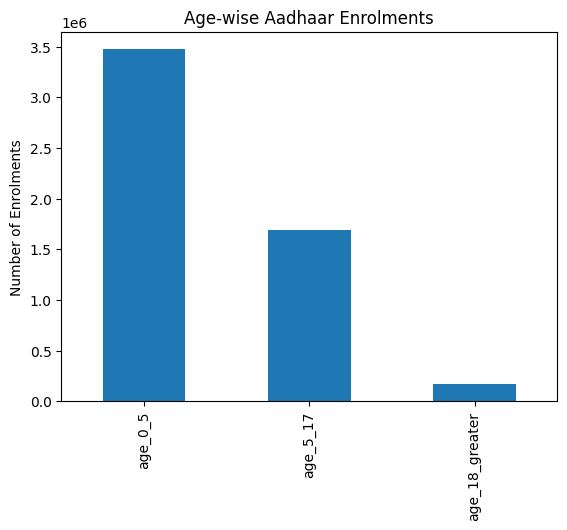

In [12]:
age_totals = enrolment_df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

age_totals.plot(kind='bar', title='Age-wise Aadhaar Enrolments')
plt.ylabel("Number of Enrolments")
plt.show()


# State-Wise Enrolment Trends

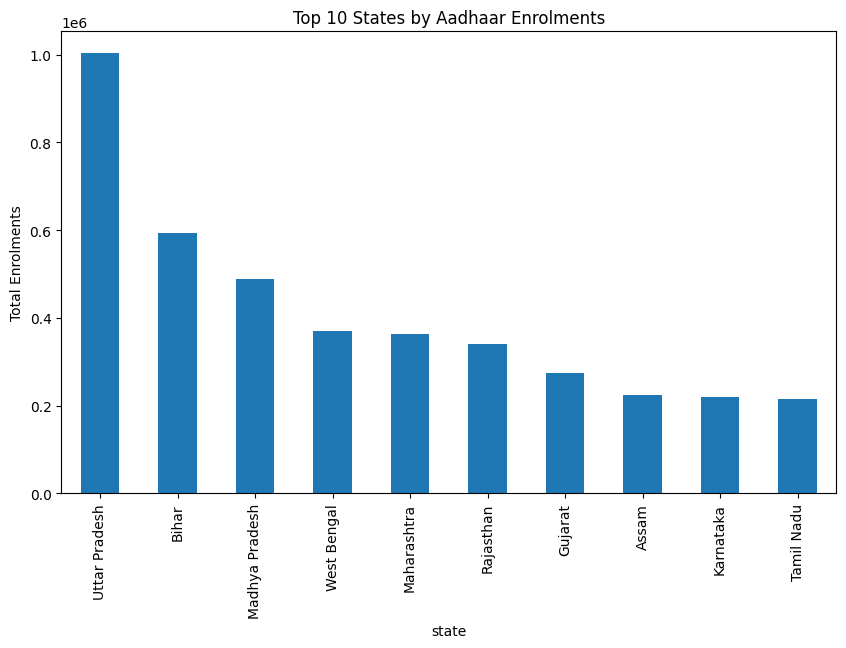

In [13]:
state_enrol = enrolment_df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
state_enrol.head(10).plot(kind='bar')
plt.title("Top 10 States by Aadhaar Enrolments")
plt.ylabel("Total Enrolments")
plt.show()


#District-Level Hotspots

In [14]:
district_enrol = enrolment_df.groupby(
    ['state', 'district']
)['total_enrolments'].sum().reset_index()

district_enrol.sort_values('total_enrolments', ascending=False).head(10)


,state,district,total_enrolments
572,Maharashtra,Thane,43142
160,Bihar,Sitamarhi,41652
910,Uttar Pradesh,Bahraich,38897
1044,West Bengal,Murshidabad,34968
1057,West Bengal,South 24 Parganas,33088
563,Maharashtra,Pune,31148
397,Karnataka,Bengaluru,30657
983,Uttar Pradesh,Sitapur,30475
771,Rajasthan,Jaipur,30341
164,Bihar,West Champaran,29913


# Time-Series Trend Analysis

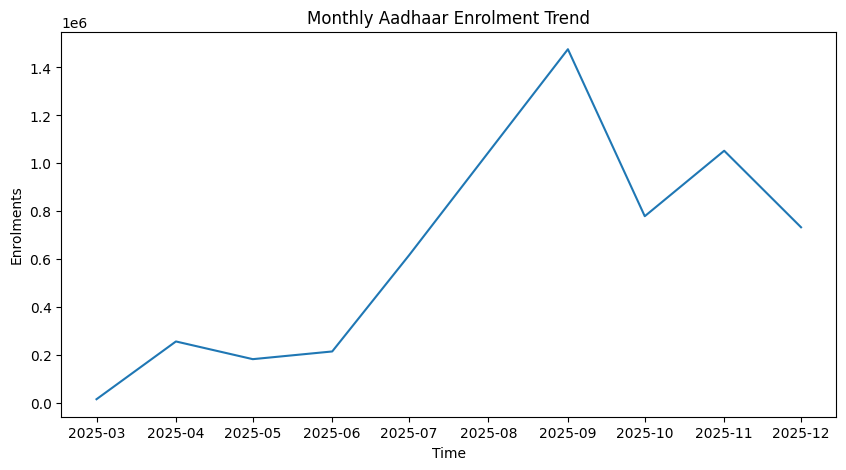

In [15]:
monthly_trend = enrolment_df.groupby(
    ['year', 'month']
)['total_enrolments'].sum().reset_index()

monthly_trend['date'] = pd.to_datetime(
    monthly_trend['year'].astype(str) + '-' + monthly_trend['month'].astype(str)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_trend['date'], monthly_trend['total_enrolments'])
plt.title("Monthly Aadhaar Enrolment Trend")
plt.xlabel("Time")
plt.ylabel("Enrolments")
plt.show()


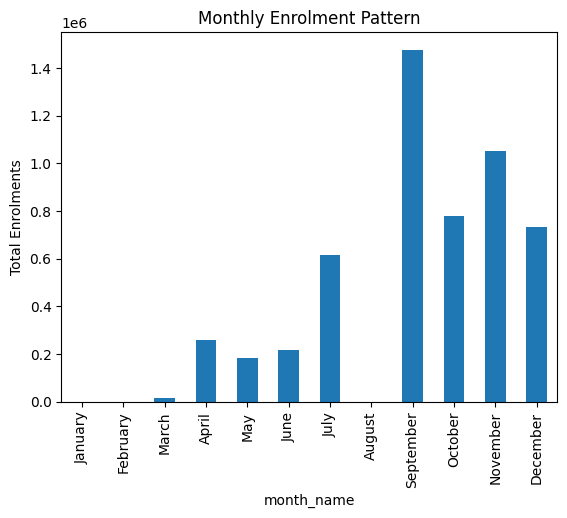

In [16]:
month_pattern = enrolment_df.groupby('month_name')['total_enrolments'].sum()

month_pattern = month_pattern.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

month_pattern.plot(kind='bar', title='Monthly Enrolment Pattern')
plt.ylabel("Total Enrolments")
plt.show()


# Anomaly Detection

In [17]:
Q1 = monthly_trend['total_enrolments'].quantile(0.25)
Q3 = monthly_trend['total_enrolments'].quantile(0.75)
IQR = Q3 - Q1

anomalies = monthly_trend[
    (monthly_trend['total_enrolments'] < Q1 - 1.5*IQR) |
    (monthly_trend['total_enrolments'] > Q3 + 1.5*IQR)
]

anomalies


,year,month,total_enrolments,date


# PIN Code Density Insight

In [18]:
pincode_enrol = enrolment_df.groupby('pincode')['total_enrolments'].sum()

pincode_enrol.describe()


,total_enrolments
count,19463.000000
mean,273.943380
std,577.620173
min,1.000000
25%,46.000000
50%,113.000000
75%,273.500000
max,15124.000000


# **dataset2**

In [19]:
from google.colab import files
uploaded = files.upload()



Saving api_data_aadhar_demographic.zip to api_data_aadhar_demographic.zip


In [20]:
!unzip api_data_aadhar_demographic.zip

Archive:  api_data_aadhar_demographic.zip
   creating: api_data_aadhar_demographic/
  inflating: api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv  
  inflating: api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv  
  inflating: api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv  
  inflating: api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv  
  inflating: api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv  


In [21]:
import glob
import pandas as pd

path = "api_data_aadhar_demographic/*.csv"
files = glob.glob(path)

demo_df = pd.concat(
    (pd.read_csv(file) for file in files),
    ignore_index=True
)

print("Combined Demographic Dataset Shape:", demo_df.shape)
demo_df.head()

Combined Demographic Dataset Shape: (2071700, 6)


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,18-11-2025,Karnataka,Hasan,573118,0,2
1,18-11-2025,Karnataka,Hasan,573124,1,3
2,18-11-2025,Karnataka,Hasan,573150,0,2
3,18-11-2025,Karnataka,Hassan,573113,0,1
4,18-11-2025,Karnataka,Hassan,573120,1,4


In [22]:
print(demo_df.columns,'\n')
print(demo_df.info(),'\n')
demo_df.isnull().sum()

Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071700 entries, 0 to 2071699
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   date           object
 1   state          object
 2   district       object
 3   pincode        int64 
 4   demo_age_5_17  int64 
 5   demo_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 94.8+ MB
None 



,0
date,0
state,0
district,0
pincode,0
demo_age_5_17,0
demo_age_17_,0


In [23]:
demo_df.duplicated().sum()


np.int64(473601)

In [24]:
before = demo_df.shape[0]
demo_df.drop_duplicates(inplace=True)
after = demo_df.shape[0]

print(f"Duplicates removed: {before - after}")
demo_df.shape

Duplicates removed: 473601


(1598099, 6)

In [25]:
demo_df = demo_df.rename(columns={
    'demo_age_17_': 'demo_age_18_plus'
})

demo_df.columns


Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_18_plus'],
      dtype='object')

In [26]:
demo_df['date'] = pd.to_datetime(
    demo_df['date'],
    format='%d-%m-%Y',
    errors='coerce'
)


In [27]:
demo_df['year'] = demo_df['date'].dt.year
demo_df['month'] = demo_df['date'].dt.month



In [28]:
demo_df['total_demo_updates'] = (
    demo_df['demo_age_5_17'] +
    demo_df['demo_age_18_plus']
)

demo_df[['demo_age_5_17', 'demo_age_18_plus', 'total_demo_updates']].head()


,demo_age_5_17,demo_age_18_plus,total_demo_updates
0,0,2,2
1,1,3,4
2,0,2,2
3,0,1,1
4,1,4,5


# Age-wise Demographic Update Analysis

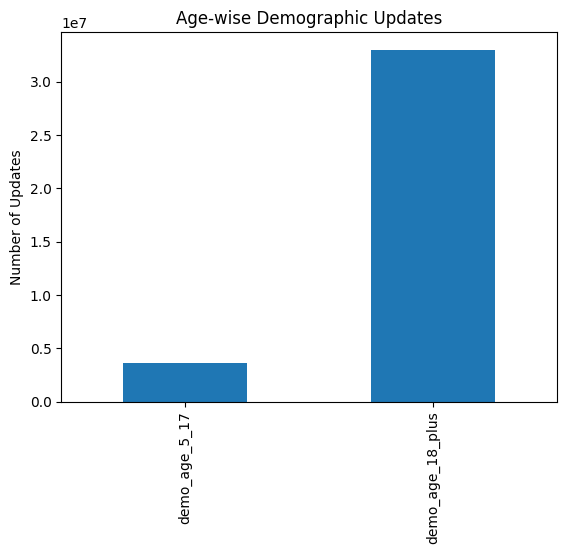

In [29]:
demo_age_totals = demo_df[['demo_age_5_17', 'demo_age_18_plus']].sum()

demo_age_totals.plot(kind='bar', title='Age-wise Demographic Updates')
plt.ylabel("Number of Updates")
plt.show()


#State-wise Demographic Update Pressure

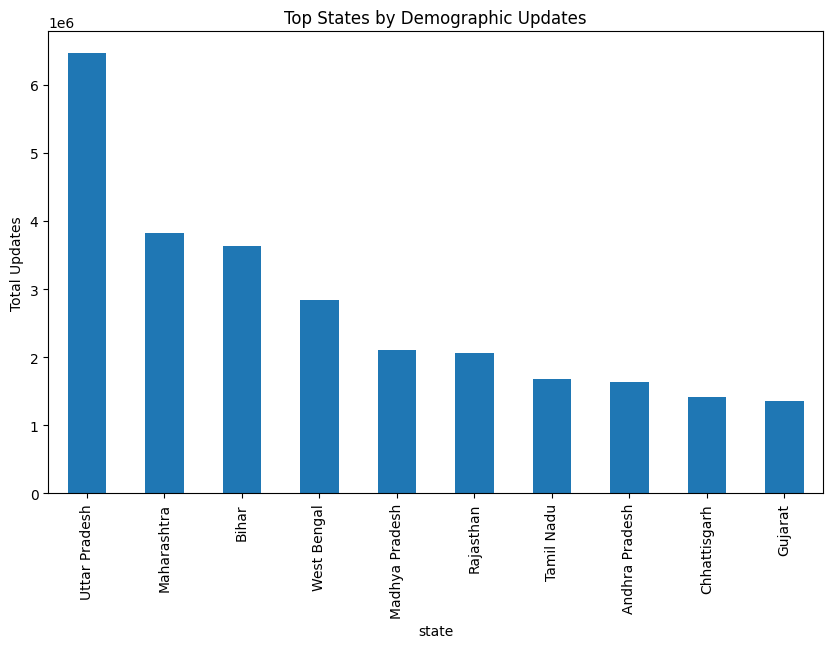

In [30]:
state_demo = demo_df.groupby('state')['total_demo_updates'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
state_demo.head(10).plot(kind='bar')
plt.title("Top States by Demographic Updates")
plt.ylabel("Total Updates")
plt.show()


# Monthly Update Trend (Time-Series)

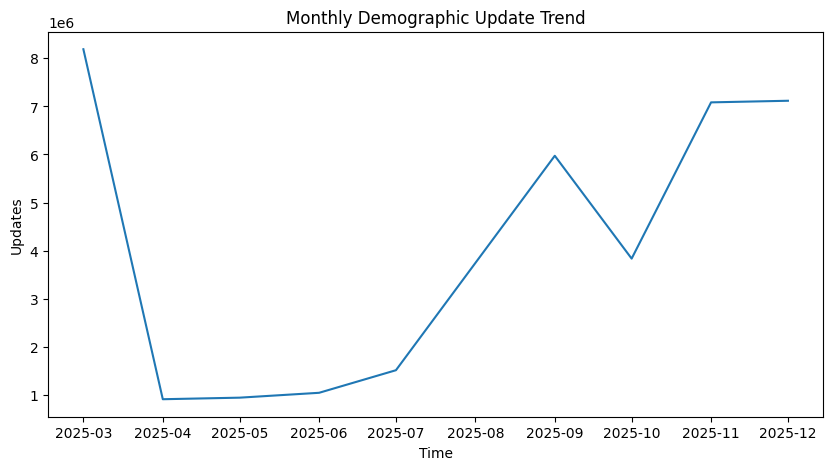

In [31]:
monthly_demo = demo_df.groupby(
    ['year', 'month']
)['total_demo_updates'].sum().reset_index()

monthly_demo['date'] = pd.to_datetime(
    monthly_demo['year'].astype(str) + '-' + monthly_demo['month'].astype(str)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_demo['date'], monthly_demo['total_demo_updates'])
plt.title("Monthly Demographic Update Trend")
plt.xlabel("Time")
plt.ylabel("Updates")
plt.show()


#Anomaly Detection

In [32]:
Q1 = monthly_demo['total_demo_updates'].quantile(0.25)
Q3 = monthly_demo['total_demo_updates'].quantile(0.75)
IQR = Q3 - Q1

demo_anomalies = monthly_demo[
    (monthly_demo['total_demo_updates'] < Q1 - 1.5 * IQR) |
    (monthly_demo['total_demo_updates'] > Q3 + 1.5 * IQR)
]

demo_anomalies


,year,month,total_demo_updates,date


merging demo+enrolment

In [37]:
monthly_enrol = enrolment_df.groupby(
    ['year','month']
)['total_enrolments'].sum().reset_index()
enrol_demo_combined = monthly_enrol.merge(
    monthly_demo,
    on=['year','month'],
    how='inner'
)

enrol_demo_combined.head()


,year,month,total_enrolments,total_demo_updates,date
0,2025,3,16582,8190152,2025-03-01
1,2025,4,257438,907282,2025-04-01
2,2025,5,183616,939768,2025-05-01
3,2025,6,215734,1040944,2025-06-01
4,2025,7,616868,1510892,2025-07-01


In [38]:
#Relationship Analysis
enrol_demo_combined[['total_enrolments','total_demo_updates']].corr()


,total_enrolments,total_demo_updates
total_enrolments,1.000000,0.388303
total_demo_updates,0.388303,1.000000


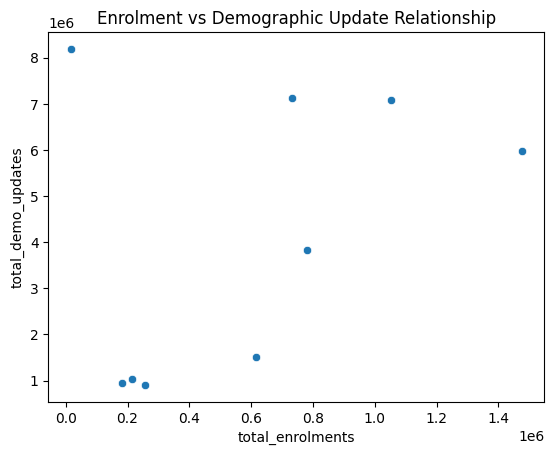

In [39]:
sns.scatterplot(
    data=enrol_demo_combined,
    x='total_enrolments',
    y='total_demo_updates'
)
plt.title("Enrolment vs Demographic Update Relationship")
plt.show()


# **3rd dataset**

In [40]:
from google.colab import files
uploaded = files.upload()


Saving api_data_aadhar_biometric.zip to api_data_aadhar_biometric.zip


In [41]:
!unzip api_data_aadhar_biometric.zip

Archive:  api_data_aadhar_biometric.zip
   creating: api_data_aadhar_biometric/
  inflating: api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv  
  inflating: api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv  
  inflating: api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv  
  inflating: api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv  


In [42]:
import glob
import pandas as pd

path = "api_data_aadhar_biometric/*.csv"
files = glob.glob(path)

bio_df = pd.concat(
    (pd.read_csv(file) for file in files),
    ignore_index=True
)

print("Combined Biometric Dataset Shape:", bio_df.shape)
bio_df.head()

Combined Biometric Dataset Shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,07-11-2025,Haryana,Yamuna Nagar,135002,4,6
1,07-11-2025,Haryana,Yamunanagar,135001,1,2
2,07-11-2025,Himachal Pradesh,Bilaspur,174004,2,2
3,07-11-2025,Himachal Pradesh,Bilaspur,174005,1,0
4,07-11-2025,Himachal Pradesh,Bilaspur,174013,3,1


In [43]:

bio_df.info()
bio_df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [44]:
bio_df.duplicated().sum()

np.int64(94896)

In [45]:
before = bio_df.shape[0]
bio_df.drop_duplicates(inplace=True)
after = bio_df.shape[0]

print(f"Duplicates removed: {before - after}")
bio_df.shape

Duplicates removed: 94896


(1766212, 6)

In [46]:
bio_df = bio_df.rename(columns={
    'bio_age_17_': 'bio_age_18_plus'
})


In [47]:
bio_df['date'] = pd.to_datetime(
    bio_df['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

bio_df['year'] = bio_df['date'].dt.year
bio_df['month'] = bio_df['date'].dt.month


In [48]:
bio_df['total_bio_updates'] = (
    bio_df['bio_age_5_17'] +
    bio_df['bio_age_18_plus']
)

bio_df[['bio_age_5_17','bio_age_18_plus','total_bio_updates']].head()


,bio_age_5_17,bio_age_18_plus,total_bio_updates
0,4,6,10
1,1,2,3
2,2,2,4
3,1,0,1
4,3,1,4


In [49]:
monthly_bio = bio_df.groupby(
    ['year','month'],
    as_index=False
)['total_bio_updates'].sum()

monthly_bio.head()


,year,month,total_bio_updates
0,2025,3,8322222
1,2025,4,8641679
2,2025,5,7879956
3,2025,6,7899289
4,2025,7,9792552


# Biometric update trend

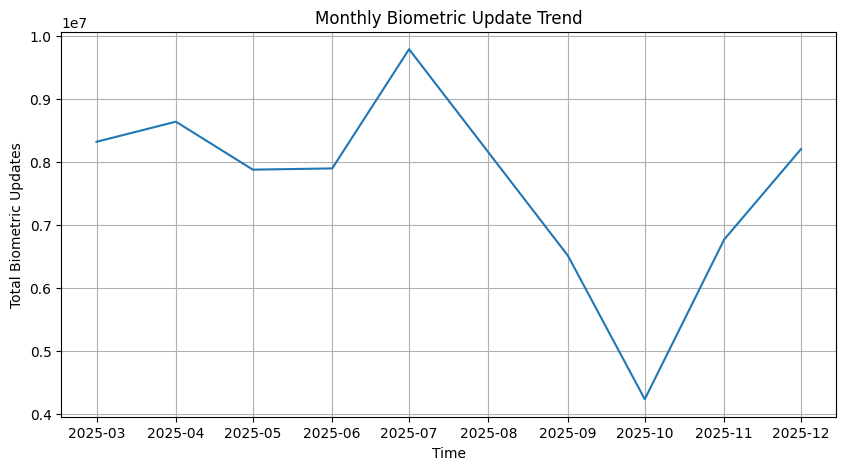

In [50]:
import matplotlib.pyplot as plt

monthly_bio['date'] = pd.to_datetime(
    monthly_bio['year'].astype(str) + '-' +
    monthly_bio['month'].astype(str)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_bio['date'], monthly_bio['total_bio_updates'])
plt.title("Monthly Biometric Update Trend")
plt.xlabel("Time")
plt.ylabel("Total Biometric Updates")
plt.grid(True)
plt.show()


In [51]:
master_df = monthly_enrol.merge(
    monthly_demo,
    on=['year','month'],
    how='inner'
)

master_df = master_df.merge(
    monthly_bio,
    on=['year','month'],
    how='inner'
)

master_df.head()


,year,month,total_enrolments,total_demo_updates,date_x,total_bio_updates,date_y
0,2025,3,16582,8190152,2025-03-01,8322222,2025-03-01
1,2025,4,257438,907282,2025-04-01,8641679,2025-04-01
2,2025,5,183616,939768,2025-05-01,7879956,2025-05-01
3,2025,6,215734,1040944,2025-06-01,7899289,2025-06-01
4,2025,7,616868,1510892,2025-07-01,9792552,2025-07-01


Predict future Aadhaar enrolment demand

In [52]:
X = master_df[['total_demo_updates', 'total_bio_updates']]
y = master_df['total_enrolments']


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.6706734347888085


In [55]:
impact_df = pd.DataFrame({
    'Predictive Indicator': X.columns,
    'Impact Weight': model.coef_
})

impact_df


,Predictive Indicator,Impact Weight
0,total_demo_updates,0.029565
1,total_bio_updates,-0.108219


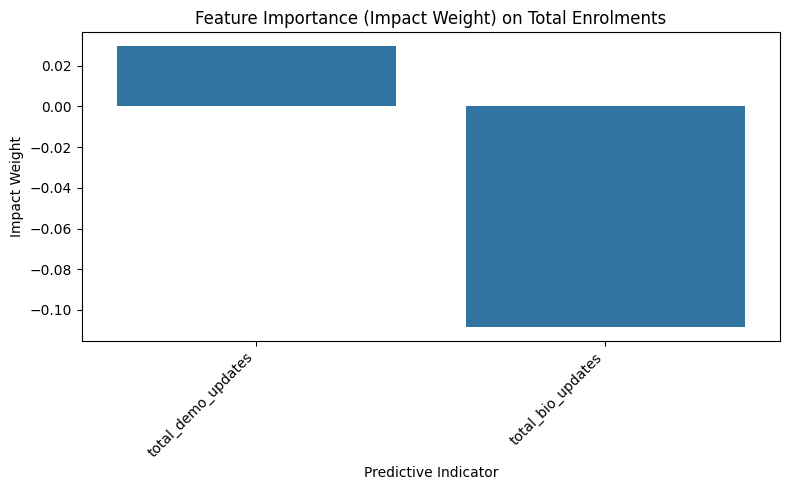

In [56]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Predictive Indicator', y='Impact Weight', data=impact_df)
plt.title('Feature Importance (Impact Weight) on Total Enrolments')
plt.xlabel('Predictive Indicator')
plt.ylabel('Impact Weight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
# Convert date columns
enrolment_df['date'] = pd.to_datetime(enrolment_df['date'], dayfirst=True)
demo_df['date'] = pd.to_datetime(demo_df['date'], dayfirst=True)
bio_df['date'] = pd.to_datetime(bio_df['date'], dayfirst=True)

# Create month
enrolment_df['month'] = enrolment_df['date'].dt.to_period('M')
demo_df['month'] = demo_df['date'].dt.to_period('M')
bio_df['month'] = bio_df['date'].dt.to_period('M')


National Aadhaar Enrolment Trend

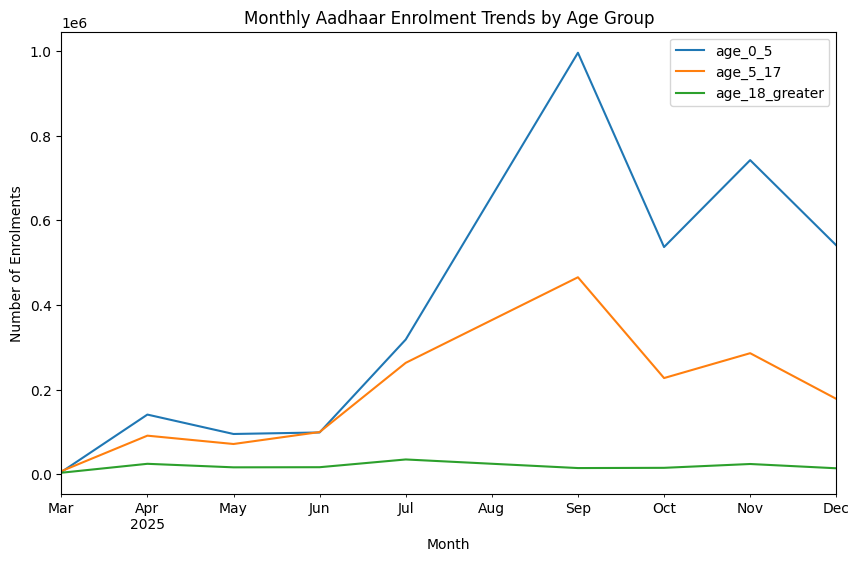

In [58]:
monthly_enrolment = enrolment_df.groupby('month')[
    ['age_0_5', 'age_5_17', 'age_18_greater']
].sum()

monthly_enrolment.plot(figsize=(10,6))
plt.title("Monthly Aadhaar Enrolment Trends by Age Group")
plt.xlabel("Month")
plt.ylabel("Number of Enrolments")
plt.show()


Adult (18+) enrolments show sharper monthly fluctuations compared to children, indicating demand sensitivity to migration, employment, and policy drives.

# Migration Pressure Index (MPI)


MPI = [Adult Enrolments(18+)]+ [Demographic Address Updates]


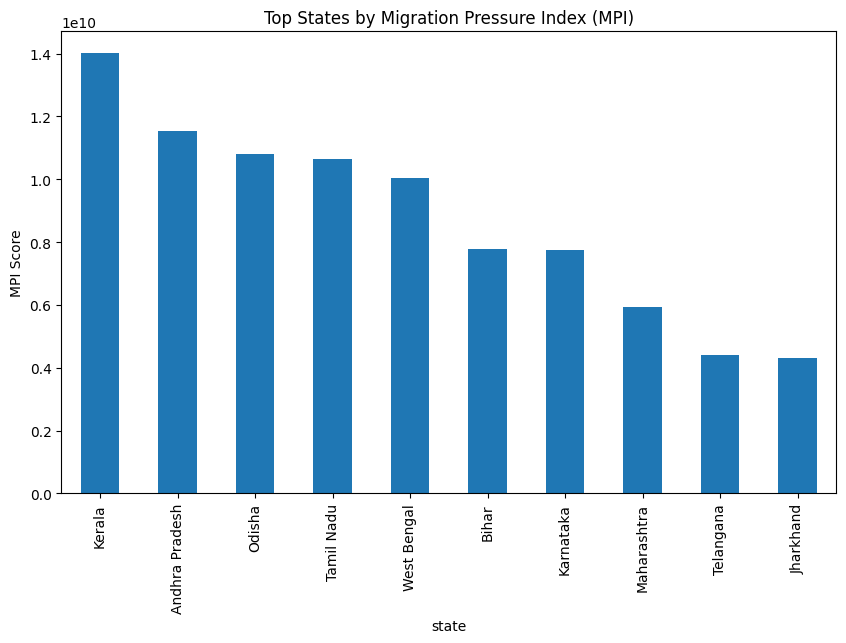

In [59]:
adult_enrol = enrolment_df.groupby(['state','month'])['age_18_greater'].sum().reset_index()
demo_updates = demo_df.groupby(['state','month']).sum(numeric_only=True).reset_index()

mpi_df = adult_enrol.merge(demo_updates, on=['state','month'])
mpi_df['MPI'] = mpi_df['age_18_greater'] + mpi_df.iloc[:,3:].sum(axis=1)

top_states = mpi_df.groupby('state')['MPI'].mean().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,6))
plt.title("Top States by Migration Pressure Index (MPI)")
plt.ylabel("MPI Score")
plt.show()



🧠 Insight

States with consistently high MPI scores act as net migration destinations and may require proactive Aadhaar service capacity planning.

#Ghost Child Awareness Index (VERY POWERFUL)

GCAI = Age_0_5 Enrolments − Biometric Updates (5–17)

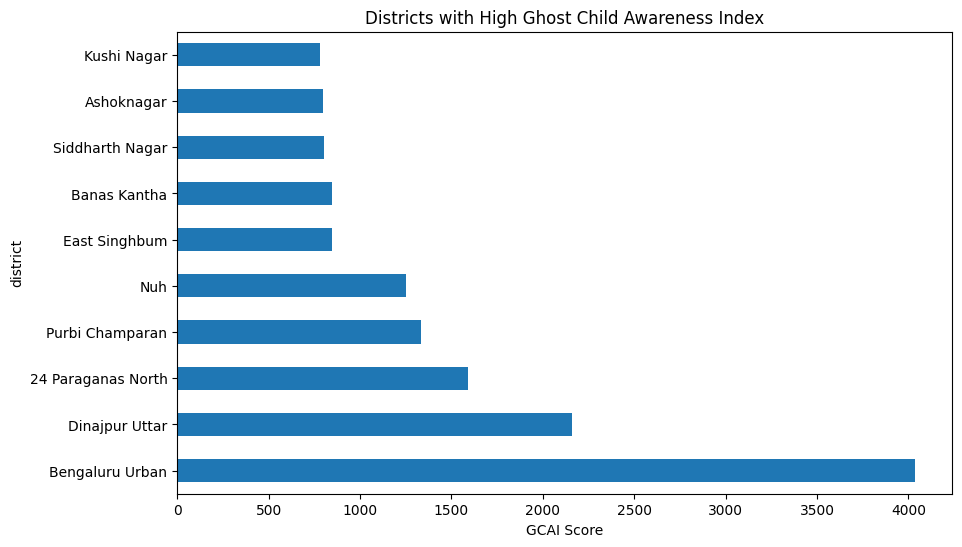

In [60]:

child_enrol = enrolment_df.groupby(['district','month'])['age_0_5'].sum().reset_index()
bio_updates = bio_df.groupby(['district','month'])['bio_age_5_17'].sum().reset_index()

ghost_df = child_enrol.merge(bio_updates, on=['district','month'], how='left').fillna(0)
ghost_df['GCAI'] = ghost_df['age_0_5'] - ghost_df['bio_age_5_17']

top_ghost = ghost_df.groupby('district')['GCAI'].mean().sort_values(ascending=False).head(10)

top_ghost.plot(kind='barh', figsize=(10,6))
plt.title("Districts with High Ghost Child Awareness Index")
plt.xlabel("GCAI Score")
plt.show()


🧠 Insight

Districts with high GCAI indicate enrolment without lifecycle follow-up, suggesting the need for targeted awareness and revalidation campaigns.
# Unusual Update Pattern Detection

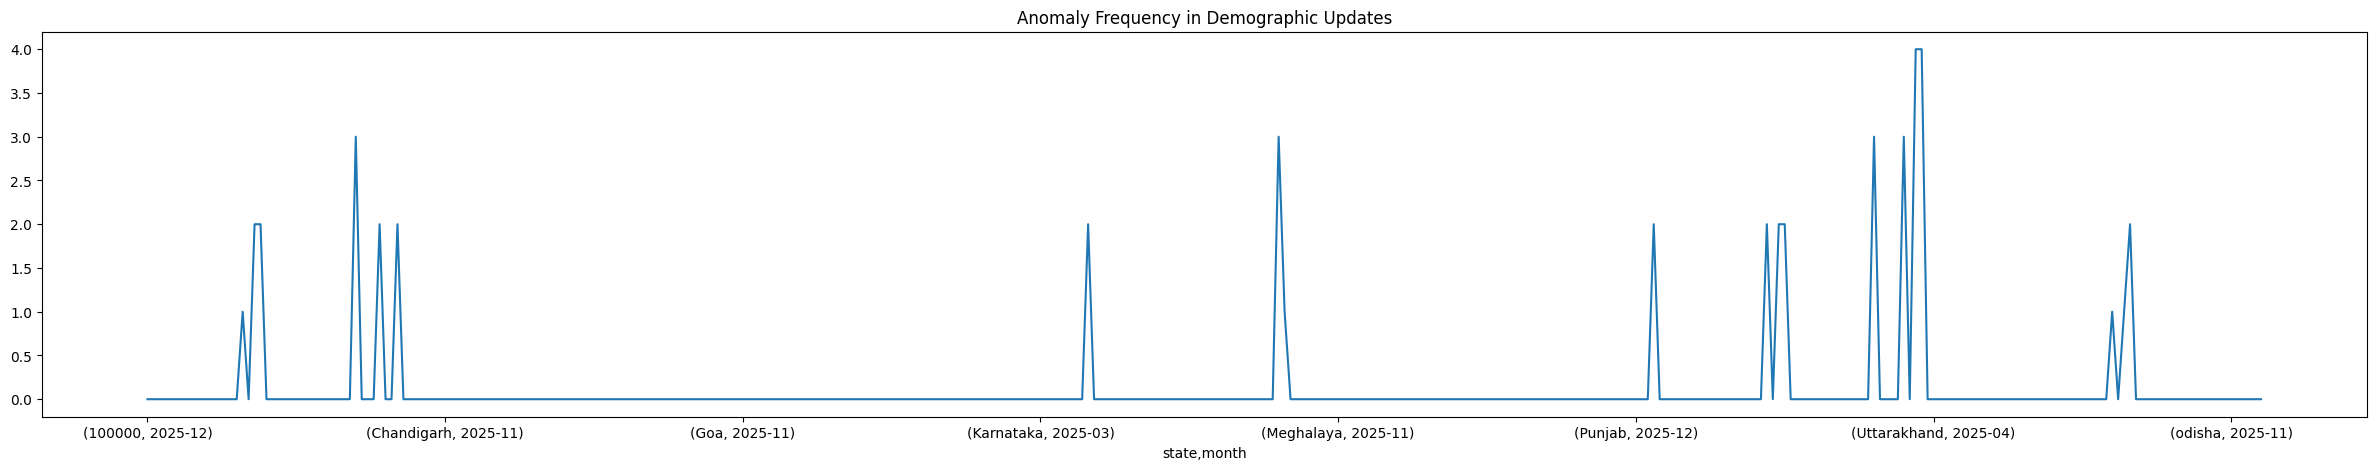

In [62]:

state_updates = demo_df.groupby(['state','month']).sum(numeric_only=True)
z_scores = (state_updates - state_updates.mean()) / state_updates.std()

anomalies = z_scores.abs() > 3
anomalies.sum(axis=1).plot(figsize=(30,5))
plt.title("Anomaly Frequency in Demographic Updates")
plt.show()



🧠 Insight

Sudden spikes in update frequency may reflect operational stress, mass corrections, or localized administrative drives.